# SDSeg Training Forward Debug

This notebook walks through the forward path used during SDSeg training on one real batch.

It covers:
- config loading
- datamodule + model instantiation
- raw batch inspection
- `model.get_input(...)`
- timestep and noise sampling
- `q_sample(...)`
- `apply_model(...)`
- latent reconstruction with `predict_start_from_noise(...)`
- manual loss computation and comparison against `model.p_losses(...)`

The notebook targets the current SDSeg training path implemented in `ldm/models/diffusion/SDSeg.py`.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "ldm").exists():
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print(f"repo_root={repo_root}")
print("Open this notebook from the repo root or from scripts/.")

repo_root=/data_ssd/caioseda/projetos/Stable-Diffusion-Seg
Open this notebook from the repo root or from scripts/.


In [2]:
import random
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import DictConfig, ListConfig, OmegaConf

from ldm.util import instantiate_from_config

print(f"torch={torch.__version__}")
print(f"cuda_available={torch.cuda.is_available()}")

/home/caioseda/miniconda3/envs/sdseg-cpython/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch=1.11.0
cuda_available=True


In [3]:
def resolve_repo_relative_paths(node, repo_root, keys=("ckpt_path", "dataset_path")):
    if isinstance(node, DictConfig):
        for key in node.keys():
            value = node[key]
            if key in keys and isinstance(value, str) and value and not Path(value).is_absolute():
                node[key] = str((repo_root / value).resolve())
            else:
                resolve_repo_relative_paths(value, repo_root, keys=keys)
    elif isinstance(node, ListConfig):
        for item in node:
            resolve_repo_relative_paths(item, repo_root, keys=keys)

CONFIG_PATH = repo_root / "configs" / "SDSeg" / "vfss-new-inca.yaml"
SPLIT = "train"
BATCH_SIZE_OVERRIDE = 4
NUM_WORKERS_OVERRIDE = 0
DATASET_PATH_OVERRIDE = None
RUN_IN_TRAIN_MODE = False
SEED = 23
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

config = OmegaConf.load(CONFIG_PATH)
resolve_repo_relative_paths(config, repo_root)
config.data.params.batch_size = BATCH_SIZE_OVERRIDE
config.data.params.num_workers = NUM_WORKERS_OVERRIDE
config.data.params.pin_memory = False

if DATASET_PATH_OVERRIDE is not None:
    for split_name in ("train", "validation", "test"):
        if split_name in config.data.params:
            config.data.params[split_name].params.dataset_path = str(DATASET_PATH_OVERRIDE)

print(f"config={CONFIG_PATH}")
print(f"model_ckpt={config.model.params.ckpt_path}")
print(f"first_stage_ckpt={config.model.params.first_stage_config.params.ckpt_path}")
print(f"cond_stage_ckpt={config.model.params.cond_stage_config.params.ckpt_path}")
print(f"split={SPLIT}, device={DEVICE}, batch_size={config.data.params.batch_size}")

config=/data_ssd/caioseda/projetos/Stable-Diffusion-Seg/configs/SDSeg/vfss-new-inca.yaml
model_ckpt=/data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/ldm/lsun_churches256/model.ckpt
first_stage_ckpt=/data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/first_stage_models/kl-f8/model.ckpt
cond_stage_ckpt=/data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/first_stage_models/kl-f8/model.ckpt
split=train, device=cuda, batch_size=4


In [4]:
model = instantiate_from_config(config.model)
model = model.to(DEVICE)
if RUN_IN_TRAIN_MODE:
    model.train()
else:
    model.eval()

datamodule = instantiate_from_config(config.data)
datamodule.prepare_data()
datamodule.setup()

if SPLIT == "train":
    loader = datamodule.train_dataloader()
elif SPLIT == "validation":
    loader = datamodule.val_dataloader()
elif SPLIT == "test":
    loader = datamodule.test_dataloader()
else:
    raise ValueError(f"Unsupported split: {SPLIT}")

batch = next(iter(loader))

print(f"model={model.__class__.__name__}")
print(f"model.training={model.training}")
print(f"conditioning_key={model.model.conditioning_key}")
print(f"first_stage_key={model.first_stage_key}, cond_stage_key={model.cond_stage_key}")
print(f"num_timesteps={model.num_timesteps}, image_size={model.image_size}, channels={model.channels}")

/home/caioseda/miniconda3/envs/sdseg-cpython/lib/python3.9/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


SDSeg: Running in eps-prediction mode
DiffusionWrapper has 294.97 M params.
Keeping EMAs of 522.
Restored KL-first-stage-model from /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/first_stage_models/kl-f8/model.ckpt with 0 missing and 56 unexpected keys
Restored Conditioning-model from /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/first_stage_models/kl-f8/model.ckpt with 0 missing and 0 unexpected keys
[ATT]: filling zeros to initialize pretrained weight 'input_blocks.0.0.weight' from torch.Size([192, 4, 3, 3]) to torch.Size([192, 8, 3, 3])
Restored only Diffusion Model from /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/models/ldm/lsun_churches256/model.ckpt with 0 missing and 0 unexpected keys
[Dataset]: Initializing VFSSIncaTrain with parameters: {'dataset_path': '/data_ssd/caioseda/data/dataset_inca_all_frames/', 'size': 256, 'window_size': 1, 'stride': 1, 'repeat_channels': True}
[Dataset]: Initializing VFSSIncaTrain with parameters: {'dataset_path': '/data_ssd

In [5]:
def summarize_value(name, value, indent=0):
    prefix = " " * indent
    if torch.is_tensor(value):
        line = f"{prefix}{name}: shape={tuple(value.shape)}, dtype={value.dtype}, device={value.device}"
        if value.numel() > 0 and torch.is_floating_point(value):
            line += f", min={value.min().item():.4f}, max={value.max().item():.4f}, mean={value.mean().item():.4f}"
        elif value.numel() > 0:
            line += f", min={value.min().item()}, max={value.max().item()}"
        print(line)
    elif isinstance(value, dict):
        print(f"{prefix}{name}: dict(keys={list(value.keys())})")
        for child_name, child_value in value.items():
            summarize_value(child_name, child_value, indent=indent + 2)
    elif isinstance(value, list):
        print(f"{prefix}{name}: list(len={len(value)})")
        for idx, child_value in enumerate(value[:3]):
            summarize_value(f"[{idx}]", child_value, indent=indent + 2)
        if len(value) > 3:
            print(f"{prefix}  ...")
    else:
        print(f"{prefix}{name}: {type(value).__name__} -> {value}")

for key, value in batch.items():
    summarize_value(key, value)


image: shape=(4, 256, 256, 3), dtype=torch.float32, device=cpu, min=-1.0000, max=1.0000, mean=-0.2482
segmentation: shape=(4, 256, 256, 3), dtype=torch.float32, device=cpu, min=-1.0000, max=1.0000, mean=-0.9528
metadata: dict(keys=['frame_id', 'video_id', 'video_frame', 'window_size', 'stride', 'window_frame_ids', 'selected_labeler'])
  frame_id: shape=(4,), dtype=torch.int64, device=cpu, min=43, max=197
  video_id: shape=(4,), dtype=torch.int64, device=cpu, min=61, max=228
  video_frame: list(len=4)
    [0]: str -> v61_f43
    [1]: str -> v111_f197
    [2]: str -> v228_f113
    ...
  window_size: shape=(4,), dtype=torch.int64, device=cpu, min=1, max=1
  stride: shape=(4,), dtype=torch.int64, device=cpu, min=1, max=1
  window_frame_ids: list(len=1)
    [0]: shape=(4,), dtype=torch.int64, device=cpu, min=43, max=197
  selected_labeler: list(len=4)
    [0]: str -> VC
    [1]: str -> VR
    [2]: str -> VR
    ...
class_id: shape=(4, 1), dtype=torch.int64, device=cpu, min=-1, max=-1
file_p

In [6]:
def plot_segmentation(segmentation, idx=0):
    '''segmentation: [B, C, H, W] or [B, K, C, H, W] where C=channels, K=window size'''
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.detach().cpu()
        if segmentation.shape[0] == 1:
            segmentation = segmentation.squeeze(0)
        elif segmentation.shape[0] > 1:
            segmentation = segmentation[idx]

        segmentation = segmentation.numpy()
        
    segmentation *= 255

    plt.figure(figsize=(6, 6))
    plt.imshow(segmentation, cmap="tab20")
    plt.axis("off")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


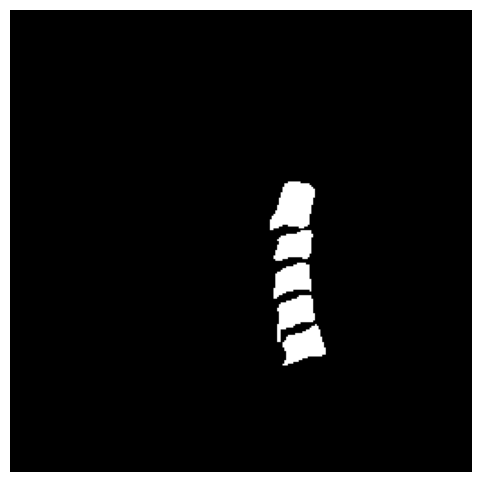

In [7]:
plot_segmentation(batch['segmentation'], 3)

In [8]:
with torch.no_grad():
    z_seg, c_raw, seg_rgb, cls_id = model.get_input(batch, model.first_stage_key)

summarize_value("z_seg", z_seg)
summarize_value("c_raw", c_raw)
summarize_value("seg_rgb", seg_rgb)
summarize_value("cls_id", cls_id)

print("\nInterpretation:")
print("- z_seg: latent segmentation target used by diffusion training")
print("- c_raw: raw conditioning input returned by get_input (image tensor when cond_stage_trainable=True)")
print("- seg_rgb: original segmentation image tensor before first-stage encoding")
print("- cls_id: class-conditioning id carried by the SDSeg API")

z_seg: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-17.4727, max=17.5157, mean=-1.5914
c_raw: shape=(4, 3, 256, 256), dtype=torch.float32, device=cuda:0, min=-1.0000, max=1.0000, mean=-0.2482
seg_rgb: shape=(4, 3, 256, 256), dtype=torch.float32, device=cuda:0, min=-255.0000, max=255.0000, mean=-61.2127
cls_id: shape=(4,), dtype=torch.int64, device=cpu, min=-1, max=-1

Interpretation:
- z_seg: latent segmentation target used by diffusion training
- c_raw: raw conditioning input returned by get_input (image tensor when cond_stage_trainable=True)
- seg_rgb: original segmentation image tensor before first-stage encoding
- cls_id: class-conditioning id carried by the SDSeg API


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


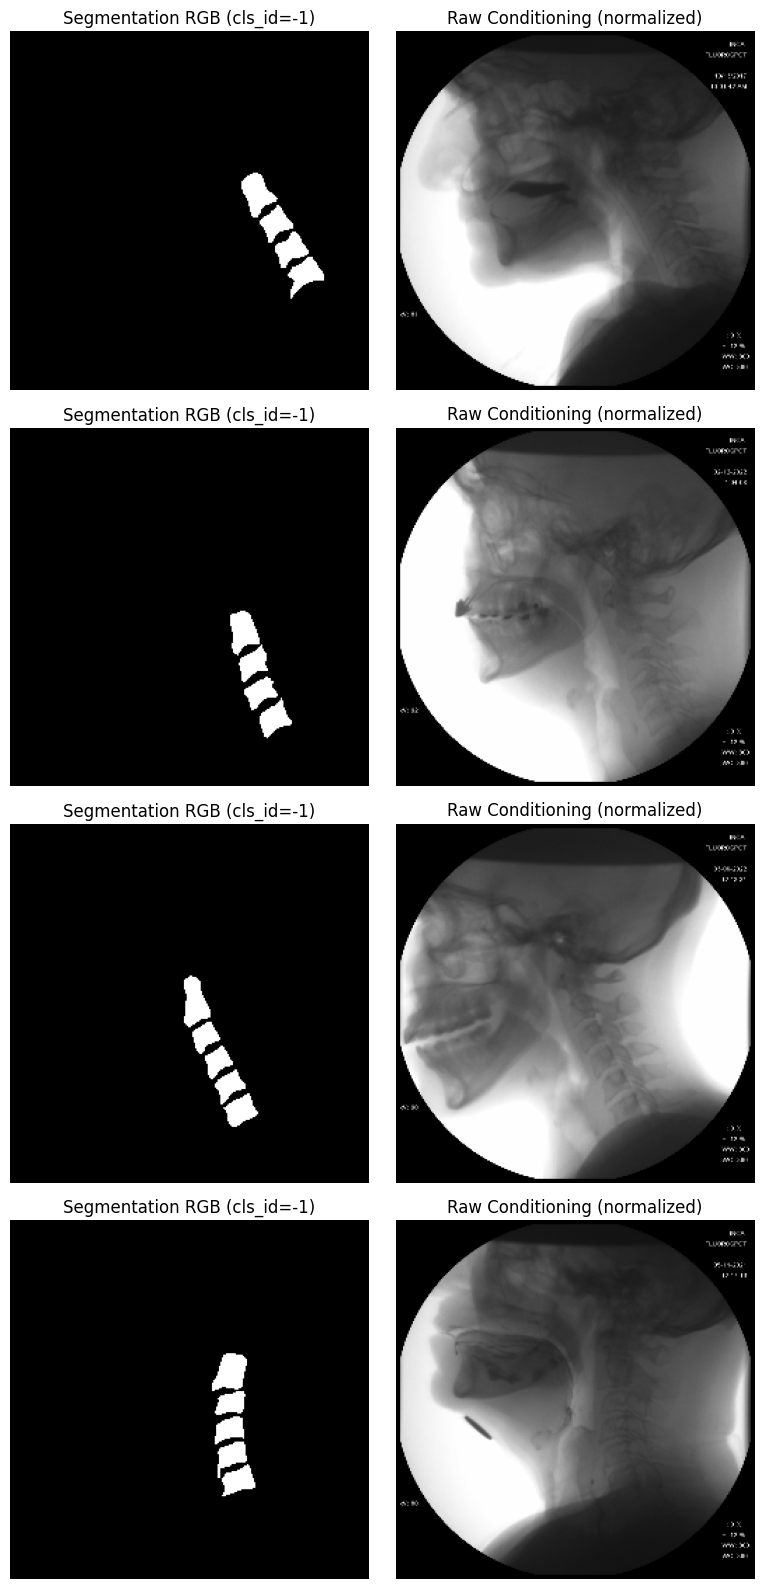

In [9]:
# Visualize the segmentation and conditioning inputs
def visualize_segmentation_and_conditioning(seg_rgb, c_raw, cls_id):
    seg_rgb_np = seg_rgb.cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, C)
    c_raw_np = c_raw.cpu().numpy().transpose(0, 2, 3, 1)  # (B, H, W, C)

    batch_size = seg_rgb_np.shape[0]
    fig, axes = plt.subplots(batch_size, 2, figsize=(8, 4 * batch_size))
    if batch_size == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(batch_size):
        axes[i, 0].imshow(seg_rgb_np[i])
        axes[i, 0].set_title(f"Segmentation RGB (cls_id={cls_id[i].item()})")
        axes[i, 0].axis("off")

        # Normalize c_raw for visualization
        c_raw_vis = (c_raw_np[i] - c_raw_np[i].min()) / (c_raw_np[i].max() - c_raw_np[i].min() + 1e-5)
        axes[i, 1].imshow(c_raw_vis)
        axes[i, 1].set_title("Raw Conditioning (normalized)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_segmentation_and_conditioning(seg_rgb, c_raw, cls_id)

In [10]:
def build_training_conditioning(model, c_raw, cls_id, t):
    c_latent = c_raw
    print(f'Building conditioning for training at timestep t={t}')
    print(f'Model conditioning_key={model.model.conditioning_key}, cond_stage_trainable={model.cond_stage_trainable}, shorten_cond_schedule={model.shorten_cond_schedule}')
    
    if model.model.conditioning_key is not None:
        if model.cond_stage_trainable:
            c_latent = model.get_learned_conditioning(c_latent)
        if model.shorten_cond_schedule:
            tc = model.cond_ids[t].to(model.device)
            c_latent = model.q_sample(x_start=c_latent, t=tc, noise=torch.randn_like(c_latent.float()))
        cond = {"c_concat": [c_latent], "c_crossattn": [cls_id]}
    else:
        cond = None
    return c_latent, cond


def inspect_training_forward(model, z_seg, c_raw, cls_id, seg_label, seed=123):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    with torch.no_grad():
        t = torch.randint(0, model.num_timesteps, (z_seg.shape[0],), device=model.device).long()
        noise = torch.randn_like(z_seg)
        c_latent, cond = build_training_conditioning(model, c_raw, cls_id, t)
        x_noisy = model.q_sample(x_start=z_seg, t=t, noise=noise)
        model_output = model.apply_model(x_noisy, t, cond)
        x_recon = model.predict_start_from_noise(x_noisy, t, noise=model_output)

        if model.parameterization == "x0":
            target = z_seg
        elif model.parameterization == "eps":
            target = noise
        else:
            raise NotImplementedError(model.parameterization)

        teste = model.get_loss(model_output, target, mean=False)
        loss_simple_per_item = model.get_loss(model_output, target, mean=False).mean([1, 2, 3])
        loss_seg_per_item = model.get_loss_seg_regression(z_seg, x_noisy, t, model_output, seg_label).mean([1, 2, 3])
        logvar_t = model.logvar.to(model.device)[t]
        loss_vlb = (model.lvlb_weights[t] * model.get_loss(model_output, target, mean=False).mean(dim=(1, 2, 3))).mean()
        manual_total = model.l_simple_weight * (loss_simple_per_item / torch.exp(logvar_t) + logvar_t).mean()
        manual_total = manual_total + (model.original_elbo_weight * loss_vlb) + loss_seg_per_item.mean()

        p_loss, p_loss_dict = model.p_losses(z_seg, cond, t, seg_label, noise=noise)
        decoded_target = model.decode_first_stage(z_seg[:1])
        decoded_recon = model.decode_first_stage(x_recon[:1])

    return {
        "t": t,
        "noise": noise,
        "c_latent": c_latent,
        "cond": cond,
        "x_noisy": x_noisy,
        "model_output": model_output,
        "x_recon": x_recon,
        "decoded_target": decoded_target,
        "decoded_recon": decoded_recon,
        "loss_simple_per_item": loss_simple_per_item,
        "loss_seg_per_item": loss_seg_per_item,
        "loss_vlb": loss_vlb,
        "manual_total": manual_total,
        "p_loss": p_loss,
        "p_loss_dict": p_loss_dict,
        "teste": teste,
    }


In [11]:
debug = inspect_training_forward(model, z_seg, c_raw, cls_id, seg_rgb, seed=123)

# for key in ["t", "c_latent", 'cond', "x_noisy", "model_output", "x_recon"]:
    # summarize_value(key, debug[key])

for key in debug.keys():
    summarize_value(key, debug[key])

print("\nLoss comparison")
print(f"manual_total={debug['manual_total'].item():.6f}")
print(f"p_losses_total={debug['p_loss'].item():.6f}")
print(f"abs_diff={abs(debug['manual_total'].item() - debug['p_loss'].item()):.6e}")
print(f"loss_simple_per_item={debug['loss_simple_per_item'].detach().cpu().numpy()}")
print(f"loss_seg_per_item={debug['loss_seg_per_item'].detach().cpu().numpy()}")
pprint({k: v.item() if torch.is_tensor(v) and v.ndim == 0 else v for k, v in debug['p_loss_dict'].items()})

Building conditioning for training at timestep t=tensor([396, 389, 232, 986], device='cuda:0')
Model conditioning_key=concat, cond_stage_trainable=True, shorten_cond_schedule=False
t: shape=(4,), dtype=torch.int64, device=cuda:0, min=232, max=986
noise: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-3.7968, max=4.0688, mean=0.0070
c_latent: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-15.7785, max=10.0822, mean=-0.0618
cond: dict(keys=['c_concat', 'c_crossattn'])
  c_concat: list(len=1)
    [0]: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-15.7785, max=10.0822, mean=-0.0618
  c_crossattn: list(len=1)
    [0]: shape=(4,), dtype=torch.int64, device=cpu, min=-1, max=-1
x_noisy: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-13.1561, max=12.2073, mean=-0.5989
model_output: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-4.1464, max=4.6818, mean=0.0014
x_recon: shape=(4, 4, 32, 32), dtype=torch.float32, devic

In [12]:
with torch.no_grad():
    torch.manual_seed(123)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(123)
    end_to_end_loss, end_to_end_loss_dict = model(z_seg, c_raw, cls_id, seg_rgb)

print(f"end_to_end_forward_loss={end_to_end_loss.item():.6f}")
pprint({k: v.item() if torch.is_tensor(v) and v.ndim == 0 else v for k, v in end_to_end_loss_dict.items()})
print("This value does not have to match the previous cell exactly because `model.forward(...)` samples its own timestep and noise.")

end_to_end_forward_loss=2.145922
{'val/loss': 2.1459221839904785,
 'val/loss_seg': 1.5401554107666016,
 'val/loss_simple': 0.6057666540145874,
 'val/loss_vlb': 0.0024030227214097977}
This value does not have to match the previous cell exactly because `model.forward(...)` samples its own timestep and noise.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Before: to_display_01: min=-1.0000, max=1.0000
Normalizing image to [0, 1]
After: to_display_01: min=0.0000, max=1.0000
Before: to_display_01: min=-1.0000, max=1.0000
Normalizing image to [0, 1]
After: to_display_01: min=0.0000, max=1.0000
Before: to_display_01: min=-1.5543, max=1.3372
Normalizing image to [0, 1]
After: to_display_01: min=-0.2771, max=1.1686
Before: to_display_01: min=-1.1190, max=0.9047
Normalizing image to [0, 1]
After: to_display_01: min=-0.0595, max=0.9523


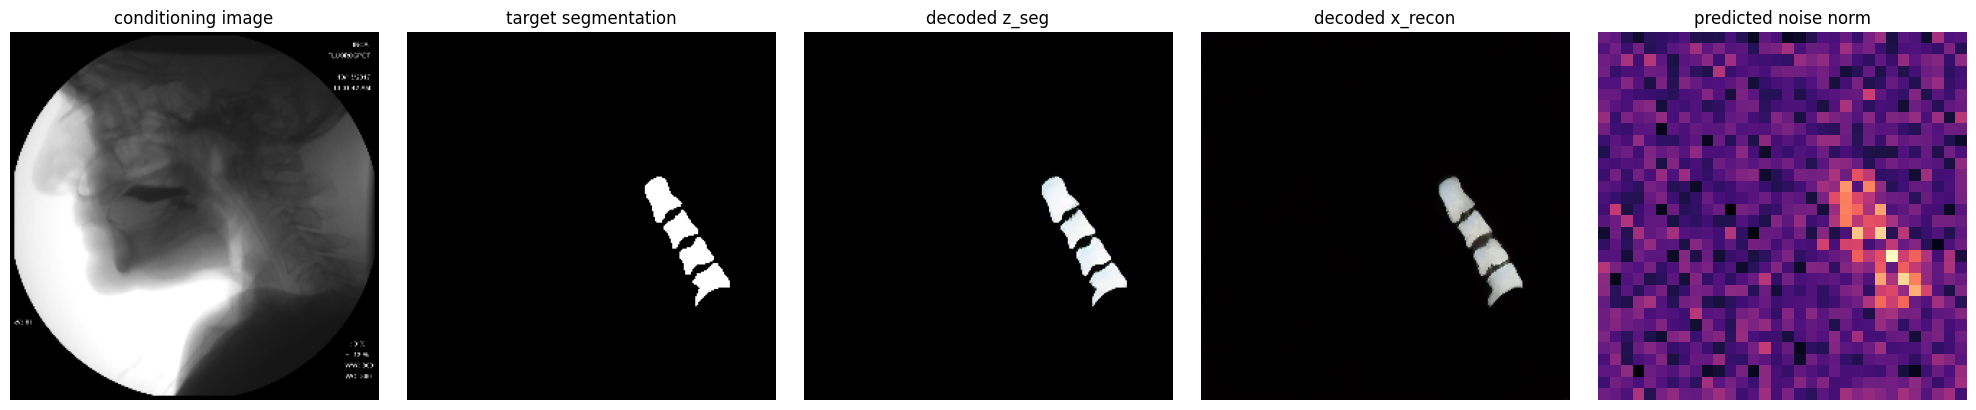

In [13]:
def to_display_01(image):
    image = image.detach().float().cpu()
    if image.ndim == 3 and image.shape[0] in (1, 3):
        image = image.permute(1, 2, 0)
    image = image.numpy()
    image_min = image.min()
    image_max = image.max()
    
    print(f"Before: to_display_01: min={image.min():.4f}, max={image.max():.4f}")
    if image_max > image_min:
        print("Normalizing image to [0, 1]")
        # image = (image - image_min) / (image_max - image_min)
        image = (image + 1.0) / 2.0
    print(f"After: to_display_01: min={image.min():.4f}, max={image.max():.4f}")
    return image


cond_image = batch["image"][0]
if cond_image.ndim == 4:
    cond_image = cond_image[cond_image.shape[0] // 2]

target_mask = batch["segmentation"][0]
pred_noise_norm = debug["model_output"][0].detach().cpu().norm(dim=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(to_display_01(cond_image))
axes[0].set_title("conditioning image")
axes[1].imshow(to_display_01(target_mask))
axes[1].set_title("target segmentation")
axes[2].imshow(to_display_01(debug["decoded_target"][0]))
axes[2].set_title("decoded z_seg")
axes[3].imshow(to_display_01(debug["decoded_recon"][0]))
axes[3].set_title("decoded x_recon")
axes[4].imshow(pred_noise_norm.numpy(), cmap="magma")
axes[4].set_title("predicted noise norm")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


# implementing window conditioning

The scientific contrbution will be testing if conditioning on nearby frames as well, with fixed window size would improve the metrics and temporal consistency of the generated masks.

## (window size = 3)

In [14]:

def inspect_training_forward_window(model, z_seg, c_raw, cls_id, seg_label, seed=123):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    with torch.no_grad():
        t = torch.randint(0, model.num_timesteps, (z_seg.shape[0],), device=model.device).long()
        noise = torch.randn_like(z_seg)
        c_latent, cond = build_training_conditioning(model, c_raw, cls_id, t)
        x_noisy = model.q_sample(x_start=z_seg, t=t, noise=noise)
        model_output = model.apply_model(x_noisy, t, cond)
        x_recon = model.predict_start_from_noise(x_noisy, t, noise=model_output)

        if model.parameterization == "x0":
            target = z_seg
        elif model.parameterization == "eps":
            target = noise
        else:
            raise NotImplementedError(model.parameterization)

        teste = model.get_loss(model_output, target, mean=False)
        loss_simple_per_item = model.get_loss(model_output, target, mean=False).mean([1, 2, 3])
        loss_seg_per_item = model.get_loss_seg_regression(z_seg, x_noisy, t, model_output, seg_label).mean([1, 2, 3])
        logvar_t = model.logvar.to(model.device)[t]
        loss_vlb = (model.lvlb_weights[t] * model.get_loss(model_output, target, mean=False).mean(dim=(1, 2, 3))).mean()
        manual_total = model.l_simple_weight * (loss_simple_per_item / torch.exp(logvar_t) + logvar_t).mean()
        manual_total = manual_total + (model.original_elbo_weight * loss_vlb) + loss_seg_per_item.mean()

        p_loss, p_loss_dict = model.p_losses(z_seg, cond, t, seg_label, noise=noise)
        decoded_target = model.decode_first_stage(z_seg[:1])
        decoded_recon = model.decode_first_stage(x_recon[:1])

    return {
        "t": t,
        "noise": noise,
        "c_latent": c_latent,
        "cond": cond,
        "x_noisy": x_noisy,
        "model_output": model_output,
        "x_recon": x_recon,
        "decoded_target": decoded_target,
        "decoded_recon": decoded_recon,
        "loss_simple_per_item": loss_simple_per_item,
        "loss_seg_per_item": loss_seg_per_item,
        "loss_vlb": loss_vlb,
        "manual_total": manual_total,
        "p_loss": p_loss,
        "p_loss_dict": p_loss_dict,
        "teste": teste,
    }


In [15]:
debug = inspect_training_forward_window(model, z_seg, c_raw, cls_id, seg_rgb, seed=123)

# for key in ["t", "c_latent", 'cond', "x_noisy", "model_output", "x_recon"]:
    # summarize_value(key, debug[key])

for key in debug.keys():
    summarize_value(key, debug[key])

print("\nLoss comparison")
print(f"manual_total={debug['manual_total'].item():.6f}")
print(f"p_losses_total={debug['p_loss'].item():.6f}")
print(f"abs_diff={abs(debug['manual_total'].item() - debug['p_loss'].item()):.6e}")
print(f"loss_simple_per_item={debug['loss_simple_per_item'].detach().cpu().numpy()}")
print(f"loss_seg_per_item={debug['loss_seg_per_item'].detach().cpu().numpy()}")
pprint({k: v.item() if torch.is_tensor(v) and v.ndim == 0 else v for k, v in debug['p_loss_dict'].items()})

Building conditioning for training at timestep t=tensor([396, 389, 232, 986], device='cuda:0')
Model conditioning_key=concat, cond_stage_trainable=True, shorten_cond_schedule=False
t: shape=(4,), dtype=torch.int64, device=cuda:0, min=232, max=986
noise: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-3.7968, max=4.0688, mean=0.0070
c_latent: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-15.7785, max=10.0822, mean=-0.0618
cond: dict(keys=['c_concat', 'c_crossattn'])
  c_concat: list(len=1)
    [0]: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-15.7785, max=10.0822, mean=-0.0618
  c_crossattn: list(len=1)
    [0]: shape=(4,), dtype=torch.int64, device=cpu, min=-1, max=-1
x_noisy: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-13.1561, max=12.2073, mean=-0.5989
model_output: shape=(4, 4, 32, 32), dtype=torch.float32, device=cuda:0, min=-4.1464, max=4.6818, mean=0.0014
x_recon: shape=(4, 4, 32, 32), dtype=torch.float32, devic

## DataLoader Stress test

In [16]:
# datamodule = instantiate_from_config(config.data)
config.data.params.persistent_workers = True
config.data.params.pin_memory = True

In [4]:
import os
def num_fds(pid=None):
    pid = pid or os.getpid()
    return len(os.listdir(f"/proc/{pid}/fd"))

num_fds(pid=3558311)


123

In [18]:
import time
from torch.utils.data import DataLoader
import torch.multiprocessing as mp
from tqdm import tqdm
import os

def num_fds(pid=None):
    pid = pid or os.getpid()
    return len(os.listdir(f"/proc/{pid}/fd"))

# mp.set_sharing_strategy("file_system")

config.data.params.batch_size = 16  
config.data.params.persistent_workers = True
config.data.params.pin_memory = True

datamodule = instantiate_from_config(config.data)
datamodule.prepare_data()
datamodule.setup()

loader = datamodule.train_dataloader()

start = time.time()
n = 0

for epoch in tqdm(range(20), desc="Epochs"):
    for batch in loader:
        n += 1

        # Force materialization of tensors
        _ = batch["image"].shape
        _ = batch["segmentation"].shape

        if n % 200 == 0:
            print(f"loaded {n} batches in {time.time() - start:.1f}s")
        
        if n % 50 == 0:
            print("main process fds:", num_fds())

print("Dataloader stress test finished ok")

[Dataset]: Initializing VFSSIncaTrain with parameters: {'dataset_path': '/data_ssd/caioseda/data/dataset_inca_all_frames/', 'size': 256, 'window_size': 1, 'stride': 1, 'repeat_channels': True}
[Dataset]: Initializing VFSSIncaTrain with parameters: {'dataset_path': '/data_ssd/caioseda/data/dataset_inca_all_frames/', 'size': 256, 'window_size': 1, 'stride': 1, 'repeat_channels': True}


Epochs:   5%|▌         | 1/20 [00:25<08:10, 25.84s/it]

main process fds: 116


Epochs:   5%|▌         | 1/20 [00:43<13:54, 43.94s/it]


KeyboardInterrupt: 